In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import specula
specula.init(0)

from lbt_synim import LBTSynIM

2026-10-09 09:51:08,548 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-09 09:51:08,761 [INFO]: [specula]: Default device is GPU number 0
2026-10-09 09:51:08,789 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-09 09:51:08,790 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [3]:
lbtidx_im = np.linalg.pinv(fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/data/Rec_20251120_085351.fits')) # LBTIdx
lbtisx_im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/im/pyr3.0_40x40_lbt_refim.fits') # LBTI sx
lucidx_im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbt_refim.fits') # LUCI dx

In [4]:
# m2c_dx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c.fits')
# m2c_sx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/m2c/asm_v32sx_m2c.fits')
# kl_dx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
# kl_sx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/ifunc/asm_v32sx_kl_inv.fits')
# mask_dx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupilstop/asm_v30dx_197pixels.fits')
# mask_sx = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv32sx/pupilstop/asm_v32sx_198pixels.fits')
# print(m2c_dx.shape,kl_dx.shape,mask_dx.shape)

In [5]:
# from scipy.io import readsav

# sav_dx = readsav('/raid1/mmenessini/LBTData/KLv30dx/phase_matrix.sav')
# sav_sx = readsav('/raid1/mmenessini/LBTData/KLv32sx/phase_matrix.sav')

# def analyse_sav(savfile):
#     print(savfile.keys())
#     mask = np.zeros([savfile['dpix'],savfile['dpix']]).flatten()
#     mask[savfile['idx_mask']] = 1
#     mask = mask.reshape([savfile['dpix'],savfile['dpix']])
#     # plt.figure()
#     # plt.imshow(mask)
#     print(savfile['dpix'])
#     m2c = savfile['klm2c']
#     act_ids = np.sum(abs(m2c),axis=0)>0
#     mode_ids = np.sum(abs(m2c),axis=1)>0
#     m2c = m2c[:,act_ids]
#     m2c = m2c[mode_ids,:]
#     kl = savfile['klmatrix']
#     klinv = np.linalg.pinv(kl)
#     print(m2c.shape)
#     print(klinv.shape)
#     print(savfile['idx_mask'].shape)
#     return m2c, mask, klinv


# m2c_dx_sav, mask_dx_sav, kl_dx_sav = analyse_sav(sav_dx)
# m2c_sx_sav, mask_sx_sav, kl_sx_sav  = analyse_sav(sav_sx)

# plt.figure()
# # plt.imshow(np.logical_xor(mask_dx,mask_dx_sav))
# plt.plot(np.sum(kl_dx_sav-kl_dx,axis=0))

In [6]:
lucidx = LBTSynIM('LUCIdx')
lbtidx = LBTSynIM('LBTIdx')
lbtisx = LBTSynIM('LBTIsx')
# misreg = lucidx.update_registration(lucidx_im)
misreg = lbtidx.update_registration(lbtidx_im)
misreg = lbtisx.update_registration(lbtisx_im)

2026-10-09 09:51:15,992 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-09 09:51:16,196 [INFO]: [specula]: Default device is GPU number 0
2026-10-09 09:51:16,287 [INFO]: [specula.simul]: Reading parameters from ./config/syn_soul_im.yml
2026-10-09 09:51:16,294 [INFO]: [specula.simul]: Reading additional parameters from /raid1/mmenessini/LBTsynIM/.output/_overrides_dl.yml
2026-10-09 09:51:16,296 [INFO]: [specula.simul]: overrides: 
2026-10-09 09:51:16,297 [INFO]: [specula.simul]: self.trigger_order=['main', 'pushpull', 'source_ngs', 'pupilstop', 'dm', 'prop', 'pyr', 'ocam', 'pyr_slopes', 'pyr_im_calibrator']
2026-10-09 09:51:16,297 [INFO]: [specula.simul]: self.trigger_order_idx=[0, 0, 0, 0, 1, 2, 3, 4, 5, 6]
2026-10-09 09:51:16,297 [WARNING]: [specula.simul]: TODO: list of inputs is not handled in output replay
2026-10-09 09:51:16,883 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/pupilstop/Pupilstop_LBTIdx_tmp.fits
2026-10-09 09:51:16,93

CalledProcessError: Command '['specula', './config/syn_soul_im.yml', '/raid1/mmenessini/LBTsynIM/.output/_overrides_dl.yml']' returned non-zero exit status 1.

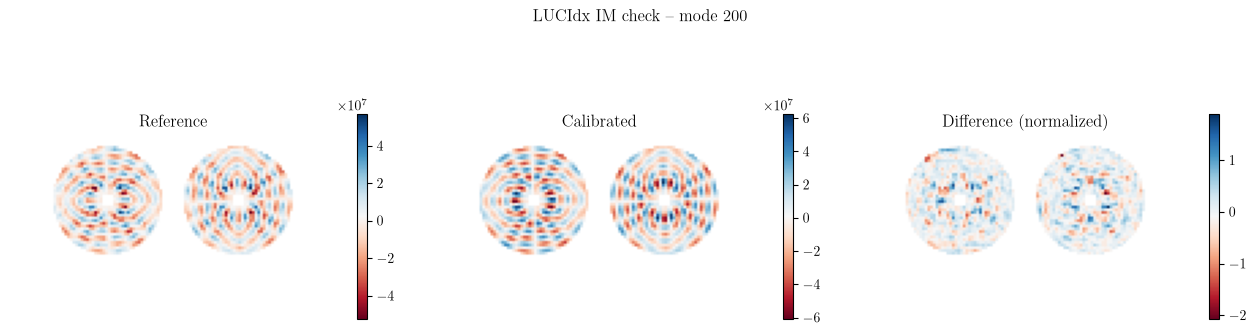

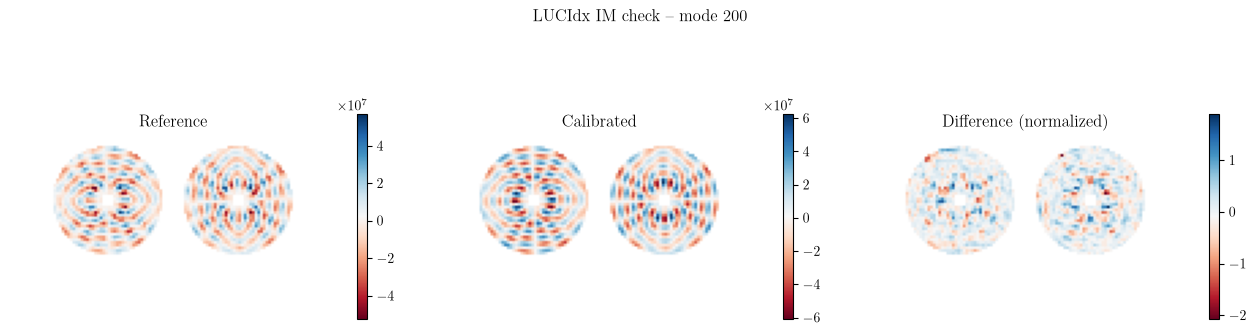

In [9]:
lucidx.plot_registration_check(mode_idx=200)
# lbtidx.plot_registration_check(mode_idx=30)
# lbtisx.plot_registration_check(mode_idx=30)

In [ ]:
# alpha = lbtisx.misreg_guess.copy()
# synim = lbtisx._synthetic_im(alpha,100,'')

# intensities = fits.getdata('/raid1/mmenessini/LBTsynIM/output/pyr_ef.fits')
# idx = 10

# plt.figure()
# plt.imshow(intensities[1+idx]-intensities[0+idx])
# plt.colorbar()

# ifunc = fits.getdata('/raid1/mmenessini/LBTsynIM/ifunc/asm_v32sx_ifunc.fits')
# pmask = fits.getdata('/raid1/mmenessini/LBTsynIM/pupilstop/asm_v32sx_pupilstop.fits')
# m2c = fits.getdata('/raid1/mmenessini/LBTsynIM/m2c/asm_v32sx_m2c.fits')
# pup_ids = fits.getdata('/raid1/mmenessini/LBTsynIM/pupils/pup_ids.fits')
# hdu = fits.open('/raid1/mmenessini/LBTsynIM/pupils/lbt_pupdata.fits')
# pupdata = hdu[1].data
# pup_mask = fits.getdata('/raid1/mmenessini/LBTsynIM/pupils/lbt_pupmask.fits')

# print(pup_ids.shape,pupdata.shape,pup_mask.shape)

# img = np.zeros(pmask.shape).flatten()
# img[pmask.flatten().astype(bool)] = m2c[:,100] @ ifunc.T
# img = img.reshape(pmask.shape)

# plt.figure()
# plt.imshow(img)
# plt.colorbar()

# raw = fits.getdata(lbtisx._im_output_path('tmp_synim_tmp'))[:, :500]

# plt.figure()
# plt.loglog(np.diag(synim.T @ synim)*1e+18)
# plt.loglog(np.diag(lbtisx_im.T @ lbtisx_im))
# plt.loglog(np.diag(raw.T @ raw)*1e+18)

# mode_idx = 30
# before = synim[:,mode_idx]
# after = synim[:,mode_idx]
# lbtisx._plot_mode_slopes_check(before, before, after, '', mode_idx)

In [ ]:
# imat_dl   = lucidx.compute_interaction_matrix(rMod=2)
# rec    = lucidx.compute_reconstructor(imat_dl, Nmodes=550)

In [ ]:
# print(imat_dl.shape,rec.shape)

In [ ]:
imat = lucidx.compute_interaction_matrix(rMod=2)
# rec = lucidx.compute_reconstructor(imat)[:imat.shape[1],:2512]

2026-10-09 08:24:19,655 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-09 08:24:19,838 [INFO]: [specula]: Default device is GPU number 0
2026-10-09 08:24:19,925 [INFO]: [specula.simul]: Reading parameters from ./config/syn_soul_im.yml
2026-10-09 08:24:19,931 [INFO]: [specula.simul]: Reading additional parameters from /raid1/mmenessini/LBTsynIM/.output/_overrides_dl.yml
2026-10-09 08:24:19,934 [INFO]: [specula.simul]: overrides: 
2026-10-09 08:24:19,934 [INFO]: [specula.simul]: self.trigger_order=['main', 'pushpull', 'source_ngs', 'pupilstop', 'dm', 'prop', 'pyr', 'ocam', 'pyr_slopes', 'pyr_im_calibrator']
2026-10-09 08:24:19,934 [INFO]: [specula.simul]: self.trigger_order_idx=[0, 0, 0, 0, 1, 2, 3, 4, 5, 6]
2026-10-09 08:24:19,935 [WARNING]: [specula.simul]: TODO: list of inputs is not handled in output replay
2026-10-09 08:24:20,524 [INFO]: [specula.simul]: Restoring: /raid1/mmenessini/LBTsynIM/pupilstop/Pupilstop_LUCIdx_20261008_120218.fits
2026-10-09

In [ ]:
imat_pc1   = lucidx.compute_interaction_matrix(rMod=2, seeing=1.0)

2026-10-08 15:43:19,511 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-10-08 15:43:19,769 [INFO]: [specula]: Default device is GPU number 0
2026-10-08 15:43:19,919 [INFO]: [specula.simul]: Reading parameters from ./config/syn_soul_im.yml
2026-10-08 15:43:19,931 [INFO]: [specula.simul]: Reading additional parameters from ./config/pc_blocks.yml
2026-10-08 15:43:19,938 [INFO]: [specula.simul]: Reading additional parameters from /raid1/mmenessini/LBTsynIM/.output/_overrides_pc.yml
2026-10-08 15:43:19,944 [INFO]: [specula.simul]: overrides: 
2026-10-08 15:43:19,945 [INFO]: [specula.simul]: self.trigger_order=['main', 'pushpull', 'source_ngs', 'pupilstop', 'seeing_random', 'dm', 'atmo_random', 'prop', 'modal_analysis_random', 'scale_random', 'dm_random', 'atmo_pc', 'ef_mode', 'pyr', 'ocam', 'pyr_slopes', 'pyr_im_calibrator']
2026-10-08 15:43:19,945 [INFO]: [specula.simul]: self.trigger_order_idx=[0, 0, 0, 0, 0, 1, 1, 2, 2, 3, 4, 5, 6, 7, 8, 9, 10]
2026-10-08 15

CalledProcessError: Command '['specula', './config/syn_soul_im.yml', './config/pc_blocks.yml', '/raid1/mmenessini/LBTsynIM/.output/_overrides_pc.yml']' returned non-zero exit status 1.

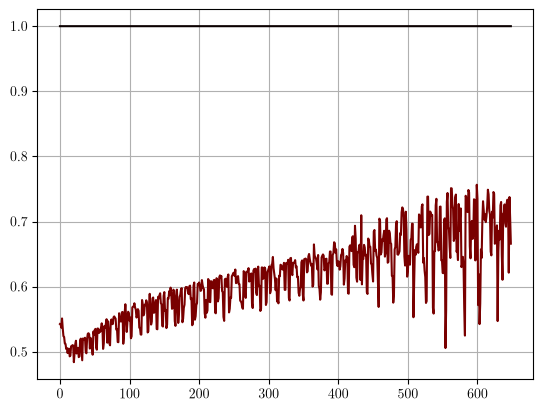

In [ ]:

rec = np.linalg.pinv(imat)

plt.figure()
plt.plot(np.diag(rec @ imat))
plt.plot(np.diag(rec @ imat_pc1))
plt.grid()

In [ ]:
# def show2d_slopes(slopes,npix=120,normalize:bool=False,title='',vmin=None,vmax=None,show=True,ppath='pyr_pupdata_40x40',newfig:bool=False):
#     if normalize:
#         slopes -= np.mean(slopes)
#         slopes_rms = np.std(slopes)
#         slopes /= slopes_rms

#     filepath=f'/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/{ppath}.fits'
#     pup_hdu = fits.open(filepath)
#     pup_ids = pup_hdu[1].data
#     fimg = np.zeros(npix**2)
#     np.put(fimg, pup_ids[:,0], slopes[:len(slopes)//2])
#     np.put(fimg, pup_ids[:,1], slopes[len(slopes)//2:])
#     f2d = fimg.reshape([npix,npix])

#     if vmin is None:
#         vmin = np.min(f2d)
#     if vmax is None:
#         vmax = np.max(f2d)
    
#     if show:
#         if newfig:
#             plt.figure()
#         plt.imshow(np.ma.masked_array(f2d,mask=np.abs(f2d)==0),origin='lower',cmap='RdBu',vmin=vmin,vmax=vmax)
#         plt.ylim([12,60])
#         plt.xlim([12,108])
#         plt.axis('off')
#         plt.title(title)
#         plt.colorbar(shrink=0.5)
#     return f2d

In [ ]:
# pupids = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pup_ids.fits')
# pyr_masks = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/lbt_pupmask_shift.fits').astype(bool)

# rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/data/Rec_20251120_085351.fits')
# refim = np.linalg.pinv(rec)

# def show_im_slopes_idx(idx:int,im=refim):
#     half_mask = pyr_masks[:60,:120].astype(bool)
#     img = np.zeros(np.size(half_mask))
#     img[half_mask.flatten()] = im[pupids,idx]
#     img = img.reshape([60,120])
#     plt.imshow(np.ma.masked_array(img,mask=img==0),origin='lower',cmap='RdBu')
#     plt.colorbar(shrink=0.5)
#     plt.ylim([12,60])
#     plt.xlim([12,120-12-1])
#     plt.axis('off')

In [ ]:
# idx = 40
# plt.figure()
# plt.subplot(2,1,2)
# show_im_slopes_idx(idx=idx)
# plt.title(f'KL{idx} measured slopes')

# aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbti_synim.fits')
# synim = aux.copy()
# synim[:2512//2,:] = aux[2512//2:,:]
# synim[2512//2:,:] = aux[:2512//2,:]*-1
# plt.subplot(2,1,1)
# f2dopt=show2d_slopes(synim[:,idx],ppath='lbt_pupdata',title=f'KL{idx} synth slopes (DL)')